In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.preprocessing import StandardScaler

In [2]:
df = pd.read_csv("ToyotaCorolla - MLR.csv")

df.head()

,Price,Age_08_04,KM,Fuel_Type,HP,Automatic,cc,Doors,Cylinders,Gears,Weight
0,13500,23,46986,Diesel,90,0,2000,3,4,5,1165
1,13750,23,72937,Diesel,90,0,2000,3,4,5,1165
2,13950,24,41711,Diesel,90,0,2000,3,4,5,1165
3,14950,26,48000,Diesel,90,0,2000,3,4,5,1165
4,13750,30,38500,Diesel,90,0,2000,3,4,5,1170


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1436 entries, 0 to 1435
Data columns (total 11 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   Price      1436 non-null   int64 
 1   Age_08_04  1436 non-null   int64 
 2   KM         1436 non-null   int64 
 3   Fuel_Type  1436 non-null   object
 4   HP         1436 non-null   int64 
 5   Automatic  1436 non-null   int64 
 6   cc         1436 non-null   int64 
 7   Doors      1436 non-null   int64 
 8   Cylinders  1436 non-null   int64 
 9   Gears      1436 non-null   int64 
 10  Weight     1436 non-null   int64 
dtypes: int64(10), object(1)
memory usage: 123.5+ KB


In [4]:
df.shape

(1436, 11)

In [5]:
df.isnull().sum()

Price        0
Age_08_04    0
KM           0
Fuel_Type    0
HP           0
Automatic    0
cc           0
Doors        0
Cylinders    0
Gears        0
Weight       0
dtype: int64

In [6]:
df.fillna(df.mean(numeric_only=True), inplace=True)

In [7]:
df.describe()

,Price,Age_08_04,KM,HP,Automatic,cc,Doors,Cylinders,Gears,Weight
count,1436.000000,1436.000000,1436.000000,1436.000000,1436.000000,1436.00000,1436.000000,1436.0,1436.000000,1436.00000
mean,10730.824513,55.947075,68533.259749,101.502089,0.055710,1576.85585,4.033426,4.0,5.026462,1072.45961
std,3626.964585,18.599988,37506.448872,14.981080,0.229441,424.38677,0.952677,0.0,0.188510,52.64112
min,4350.000000,1.000000,1.000000,69.000000,0.000000,1300.00000,2.000000,4.0,3.000000,1000.00000
25%,8450.000000,44.000000,43000.000000,90.000000,0.000000,1400.00000,3.000000,4.0,5.000000,1040.00000
50%,9900.000000,61.000000,63389.500000,110.000000,0.000000,1600.00000,4.000000,4.0,5.000000,1070.00000
75%,11950.000000,70.000000,87020.750000,110.000000,0.000000,1600.00000,5.000000,4.0,5.000000,1085.00000
max,32500.000000,80.000000,243000.000000,192.000000,1.000000,16000.00000,5.000000,4.0,6.000000,1615.00000


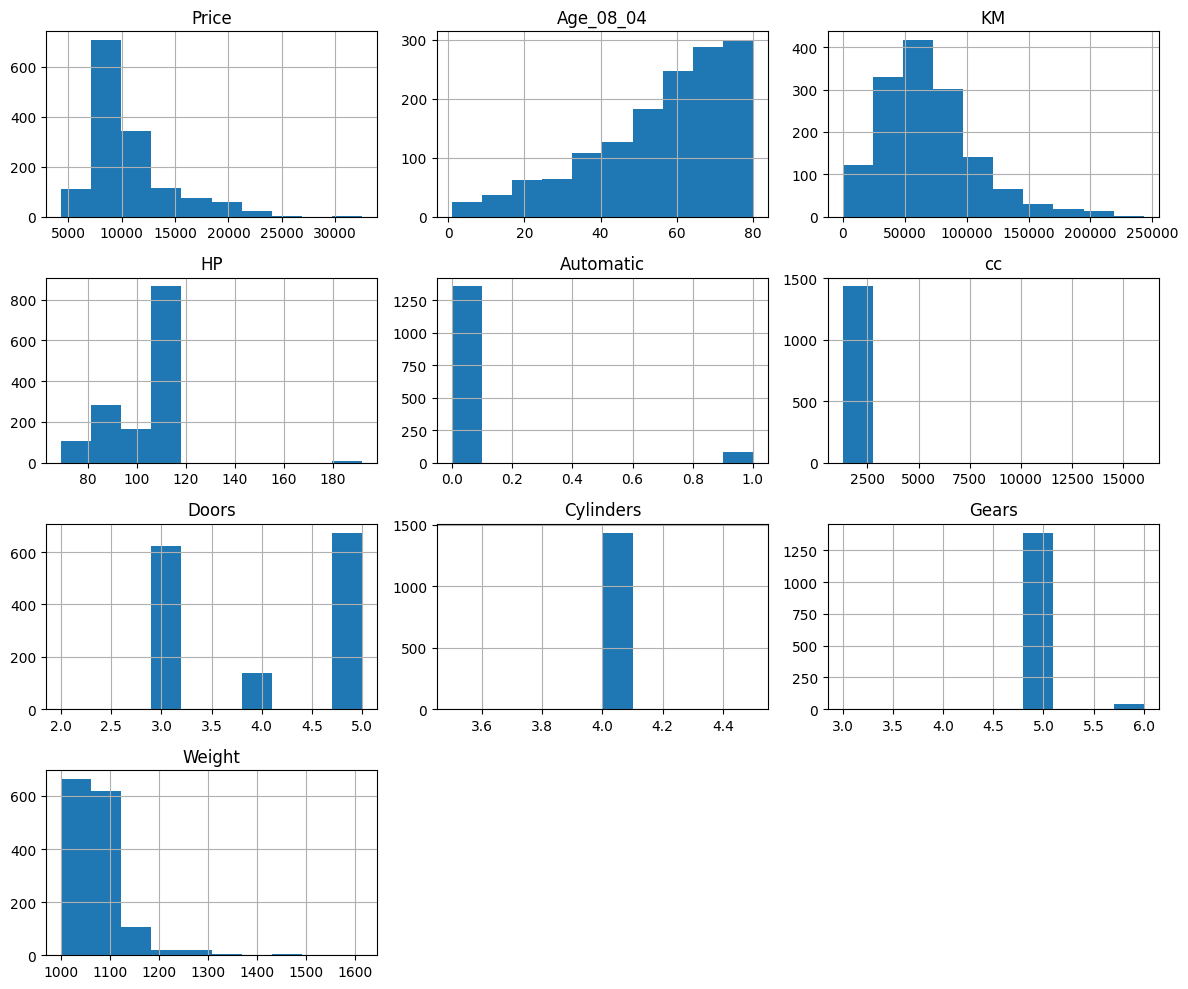

In [8]:
df.hist(figsize=(12,10))

plt.tight_layout()
plt.show()

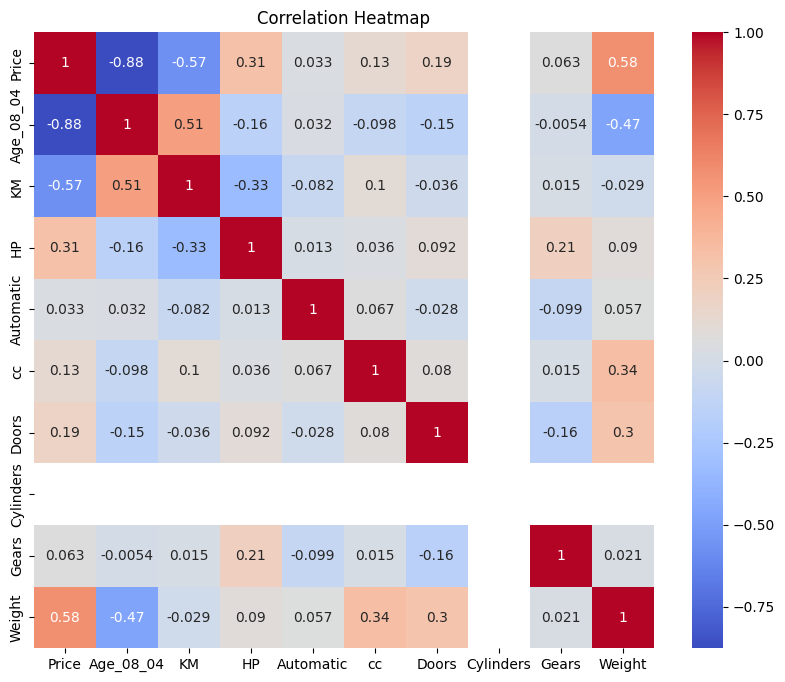

In [9]:
plt.figure(figsize=(10,8))

sns.heatmap(df.corr(numeric_only=True), annot=True, cmap="coolwarm")

plt.title("Correlation Heatmap")

plt.show()

In [10]:
df = pd.get_dummies(df, columns=["Fuel_Type"], drop_first=True)

df.head()

,Price,Age_08_04,KM,HP,Automatic,cc,Doors,Cylinders,Gears,Weight,Fuel_Type_Diesel,Fuel_Type_Petrol
0,13500,23,46986,90,0,2000,3,4,5,1165,True,False
1,13750,23,72937,90,0,2000,3,4,5,1165,True,False
2,13950,24,41711,90,0,2000,3,4,5,1165,True,False
3,14950,26,48000,90,0,2000,3,4,5,1165,True,False
4,13750,30,38500,90,0,2000,3,4,5,1170,True,False


In [11]:
X = df.drop("Price", axis=1)

y = df["Price"]

In [12]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [13]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [14]:
model1 = LinearRegression()

model1.fit(X_train, y_train)

y_pred1 = model1.predict(X_test)

In [15]:
coeff = pd.DataFrame(model1.coef_, X.columns, columns=["Coefficient"])

print(coeff)

                   Coefficient
Age_08_04        -2.267295e+03
KM               -6.116544e+02
HP                2.083499e+02
Automatic         3.439713e+01
cc               -1.416192e+01
Doors            -5.746780e+01
Cylinders         8.526513e-14
Gears             1.093404e+02
Weight            1.316818e+03
Fuel_Type_Diesel -2.172217e+01
Fuel_Type_Petrol  4.580477e+02


In [16]:
print("MAE:", mean_absolute_error(y_test, y_pred1))

print("MSE:", mean_squared_error(y_test, y_pred1))

print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred1)))

print("R2 Score:", r2_score(y_test, y_pred1))

MAE: 990.8872739193968
MSE: 2203043.823143704
RMSE: 1484.265415329652
R2 Score: 0.8348888040611082


In [17]:
ridge = Ridge(alpha=1.0)

ridge.fit(X_train, y_train)

y_pred2 = ridge.predict(X_test)

In [18]:
lasso = Lasso(alpha=0.1)

lasso.fit(X_train, y_train)

y_pred3 = lasso.predict(X_test)

In [19]:
print("Lasso R2 Score:", r2_score(y_test, y_pred3))

Lasso R2 Score: 0.8349116135580272


In [20]:
results = pd.DataFrame({

"Model": ["Linear Regression","Ridge","Lasso"],

"R2 Score":[
r2_score(y_test,y_pred1),
r2_score(y_test,y_pred2),
r2_score(y_test,y_pred3)
]

})

print(results)

               Model  R2 Score
0  Linear Regression  0.834889
1              Ridge  0.835046
2              Lasso  0.834912


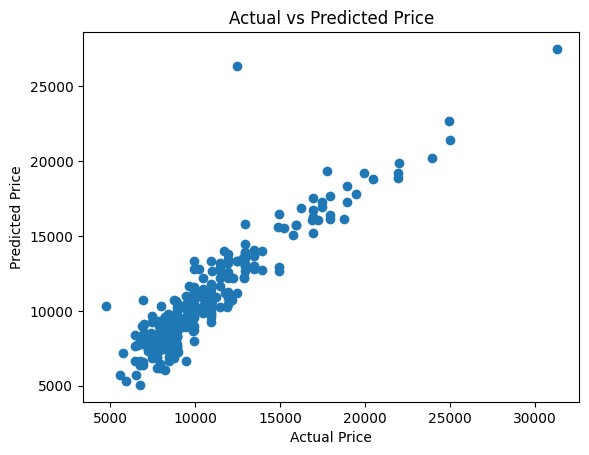

In [21]:
plt.scatter(y_test, y_pred1)

plt.xlabel("Actual Price")

plt.ylabel("Predicted Price")

plt.title("Actual vs Predicted Price")

plt.show()

Interview Questions:


1.What is Normalization & Standardization and how is it helpful?

Ans 1.

Normalization (Min-Max Scaling)

Normalization ek scaling technique hai jo values ko 0 to 1 ke range me convert karti hai.

Formula:


-When to use?

Jab data non-Gaussian ho

Jab outliers bahut kam ho

Neural Networks, KNN, K-Means jaise algorithms me

 Standardization (Z-Score Scaling)

Standardization data ko mean = 0 aur standard deviation = 1 banata hai.

Formula:   Xstd = X − mean/std
                  


- When to use?

Jab data Gaussian shape (bell curve) jaisa ho

Jab outliers present ho

Linear Regression, Logistic Regression, SVM, PCA

2.What techniques can be used to address multicollinearity in multiple linear regression?

Ans 2.
    Multicollinearity matlab independent variables ek dusre ke sath highly correlated ho jate hain.
Isse model unstable, coefficients unreliable ho jate hain.

 Techniques to Fix Multicollinearity
️  1 Remove Highly Correlated Features

Correlation matrix check karo → jisme correlation > 0.80 ho → unme se 1 feature remove kar do.
️  2 Variance Inflation Factor (VIF)

VIF > 10
→ multicollinearity high
→ feature drop ya transform karo

️ 3 Regularization (Ridge / Lasso)
Ridge Regression: Shrinks coefficients → reduces multicollinearity
Lasso Regression: Coefficients ko zero bana deta hai → feature selection bhi ho jata hai
️ 4 Principal Component Analysis (PCA)

Highly correlated variables ko combine karke new independent components banata hai.

️ 5 Collect More Data

Kabhi-kabhi multicollinearity small dataset size ki wajah se hoti hai.

Age and KM negatively affect price

Higher HP and Weight increase price

Regularization (Ridge, Lasso) reduces overfitting

Best model selected using R² Score

Conclusion

Multiple Linear Regression was used to predict the price of Toyota Corolla cars based on several features such as age, kilometers driven, horsepower, and weight. Exploratory data analysis helped identify relationships between variables. Three models were built: Linear Regression, Ridge Regression, and Lasso Regression. Model performance was evaluated using R², MAE, and RMSE metrics. Regularization techniques helped improve model stability and reduce multicollinearity effects.